In [1]:
# Install required packages
pip install -r requirements.txt

Looking in indexes: https://download.pytorch.org/whl/cu124
INFO: pip is looking at multiple versions of torchaudio to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 189.9 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 123.2 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 45.9 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 153.1 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 178.2 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 130.8 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 193.1 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 199.3 MB/s  0:00:0200:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 254.4 MB/s  0:00:0100:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 268.3

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 291.8 MB/s  0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 193.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 220.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 768.4/768.4 MB 179.3 MB/s  0:00:020:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 54.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.1/150.1 MB 287.8 MB/s  0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.2/6.2 MB 50.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.7/166.7 MB 262.1 MB/s  0:00:000:00:0100:01
  Attempting uninstall: triton
    Found existing installation: triton 3.4.0
    Uninstalling triton-3.4.0:
      Successfully uninstalled triton-3.4.0
  Attempting uninstall: nvidia-cusparselt-cu12━━  0/18 [triton]
    Found existing installation: nvidia-cusparselt-cu12 0.7.10m [triton]
    Uninstalling nvidia-cusparselt-cu12-0.7.1:0m  

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LambdaLR

from torchvision import models, transforms

import os
import json
import numpy as np
from PIL import Image
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
import warnings
import math

warnings.filterwarnings('ignore')

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Device: {device}")
if device.type == 'cuda':
    print(f"  GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"  CUDA Version: {torch.version.cuda}")
    torch.cuda.empty_cache()
else:
    print("  ⚠️  WARNING: GPU not available! Training will be very slow.")
    print("  Go to Runtime → Change runtime type → Select GPU")

✓ Device: cuda
  GPU Name: NVIDIA H200
  GPU Memory: 150.12 GB
  CUDA Version: 12.4


In [4]:
!pip install kagglehub
import kagglehub # Download latest version
path = kagglehub.dataset_download("zemddx/vist-data")
print("Path to dataset files:", path)

  8%|▊         | 293M/3.77G [00:03<00:23, 160MB/s]  

100%|██████████| 3.77G/3.77G [00:24<00:00, 162MB/s] 

Extracting files...


Path to dataset files: /teamspace/studios/this_studio/.cache/kagglehub/datasets/zemddx/vist-data/versions/2


In [7]:
import os
import shutil
import time


# 2️⃣ Source: KaggleHub cache (already downloaded)
SOURCE_PATH = "/teamspace/studios/this_studio/.cache/kagglehub/datasets/zemddx/vist-data/versions/2"

# 3️⃣ Destination: Google Drive
DEST_PATH = "/teamspace/studios/this_studio/vist_data"

# 4️⃣ Create destination folder if it doesn't exist
os.makedirs(DEST_PATH, exist_ok=True)

print("From:", SOURCE_PATH)
print("To:  ", DEST_PATH)

start = time.time()

# 5️⃣ Copy safely (skips if already exists)
if not os.listdir(DEST_PATH):
    shutil.copytree(
        SOURCE_PATH,
        DEST_PATH,
        dirs_exist_ok=True
    )
    print("✅ Dataset copied successfully.")
else:
    print("⚠️ Dataset already exists in Drive. Skipping copy.")

end = time.time()
print(f"⏱️ Time taken: {(end - start)/60:.2f} minutes")

# 6️⃣ Verify
print("\n📁 Files in Google Drive dataset folder:")
for item in os.listdir(DEST_PATH):
    print("-", item)

print("\n✅ Dataset is now permanently stored in Google Drive.")

From: /teamspace/studios/this_studio/.cache/kagglehub/datasets/zemddx/vist-data/versions/2
To:   /teamspace/studios/this_studio/vist_data
✅ Dataset copied successfully.
⏱️ Time taken: 0.23 minutes

📁 Files in Google Drive dataset folder:
- val.story-in-sequence.json
- train.story-in-sequence.json
- test.story-in-sequence.json
- train_data
- val_data

✅ Dataset is now permanently stored in Google Drive.


In [8]:
dataset_path = '/teamspace/studios/this_studio/vist_data'

# Find JSON files
json_files = [f for f in os.listdir(dataset_path) if f.endswith('.json')]
print(f"📋 JSON files found: {json_files}\n")

# Load and inspect first JSON file
if 'train.story-in-sequence.json' in json_files:
    json_file = 'train.story-in-sequence.json'
else:
    json_file = json_files[0]

json_path = os.path.join(dataset_path, json_file)

print(f"Inspecting {json_file}...")
with open(json_path, 'r') as f:
    sample_data = json.load(f)

# Handle different data formats
if isinstance(sample_data, dict):
    first_key = list(sample_data.keys())[0]
    sample_story = sample_data[first_key]
    print(f"Data format: Dictionary")
    print(f"Number of stories: {len(sample_data)}")
elif isinstance(sample_data, list):
    sample_story = sample_data[0]
    print(f"Data format: List")
    print(f"Number of stories: {len(sample_data)}")

print(f"\n📖 Sample story structure:")
print(json.dumps(sample_story, indent=2)[:500])

print(f"\nKey fields in story:")
if isinstance(sample_story, dict):
    for key in sample_story.keys():
        if key in ['story_id', 'url_o', 'sentences', 'descriptions']:
            value = sample_story[key]
            if isinstance(value, list):
                print(f"  ✓ {key}: {len(value)} items")
            else:
                print(f"  ✓ {key}: {value}")

📋 JSON files found: ['val.story-in-sequence.json', 'train.story-in-sequence.json', 'test.story-in-sequence.json']

Inspecting train.story-in-sequence.json...
Data format: Dictionary
Number of stories: 5

📖 Sample story structure:
[
  {
    "datetaken": "2008-06-30 07:33:43",
    "license": "5",
    "title": "Moreton Bay Fig 1877",
    "text": "",
    "album_id": "72157605930515606",
    "longitude": "-119.692879",
    "url_o": "https://farm3.staticflickr.com/2078/2626977325_2b7696990c_o.jpg",
    "secret": "bec0ff3596",
    "media": "photo",
    "latitude": "34.414760",
    "id": "2626977325",
    "tags": "santabarbara"
  },
  {
    "datetaken": "2008-06-30 07:34:04",
    "license": "5",
    "title": "Santa Barbara",
   

Key fields in story:


In [9]:
import json
import os
from collections import defaultdict
import torch
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
import requests
from io import BytesIO
import sentencepiece as spm
import tempfile


class VISTDataset(Dataset):
    """
    ✅ VIST Dataset Loader with SentencePiece Subword Tokenization
    (Word-level vocab completely removed)
    """

    def __init__(
        self,
        dataset_path,
        json_file,
        transform=None,
        img_size=224,
        build_tokenizer=True,
        sp_model=None,
        vocab_size=8000,
        max_len=200
    ):
        self.dataset_path = dataset_path
        self.json_file = json_file
        self.img_size = img_size
        self.max_len = max_len

        # ---------------- IMAGE FOLDER ----------------
        if "train" in json_file:
            self.image_folder = "train_data"
        elif "val" in json_file:
            self.image_folder = "val_data"
        elif "test" in json_file:
            self.image_folder = "test_data"
        else:
            self.image_folder = None

        # ---------------- TRANSFORMS ----------------
        self.transform = transform or transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]
            )
        ])

        print(f"📂 Loading: {os.path.join(dataset_path, json_file)}")

        with open(os.path.join(dataset_path, json_file), 'r', encoding='utf-8') as f:
            data = json.load(f)

        # ---------------- PARSE JSON ----------------
        images_list = data.get("images", [])
        annotations_raw = data.get("annotations", [])

        # ---------------- PHOTO → URL ----------------
        self.photo_url_map = {}
        for img in images_list:
            pid = img.get("id") or img.get("photo_flickr_id")
            url = img.get("url_o")
            if pid and url:
                self.photo_url_map[str(pid)] = url

        # ---------------- FLATTEN ANNOTATIONS ----------------
        flat_annotations = []
        for a in annotations_raw:
            if isinstance(a, list):
                flat_annotations.extend(a)
            elif isinstance(a, dict):
                flat_annotations.append(a)

        # ---------------- GROUP STORIES ----------------
        stories_dict = defaultdict(list)
        for ann in flat_annotations:
            stories_dict[ann.get("album_id")].append(ann)

        self.stories = []
        for album_id, anns in stories_dict.items():
            try:
                anns.sort(key=lambda x: int(x.get("worker_arranged_photo_order", 0)))
            except:
                pass

            if len(anns) >= 5:
                self.stories.append({
                    "story_id": album_id,
                    "photo_ids": [str(a.get("photo_flickr_id")) for a in anns[:5]],
                    "texts": [a.get("original_text", "") for a in anns[:5]]
                })

        print(f"✅ Built {len(self.stories)} stories")

        # ---------------- SENTENCEPIECE ----------------
        if sp_model is not None:
            self.sp = sp_model
            print("📚 Using shared SentencePiece tokenizer")
        else:
            self.sp = spm.SentencePieceProcessor()
            if build_tokenizer:
                self._train_sentencepiece(vocab_size)

        self.pad_id = self.sp.pad_id()
        self.bos_id = self.sp.bos_id()
        self.eos_id = self.sp.eos_id()

        print(f"🔤 SentencePiece vocab size: {self.sp.get_piece_size()}")

    # ======================================================
    # TRAIN SENTENCEPIECE
    # ======================================================
    def _train_sentencepiece(self, vocab_size):
        print("🔤 Training SentencePiece tokenizer...")

        with tempfile.NamedTemporaryFile(mode="w", delete=False) as f:
            for s in self.stories:
                f.write(" ".join(s["texts"]) + "\n")
            corpus_path = f.name

        model_prefix = os.path.join(tempfile.gettempdir(), "vist_sp")

        spm.SentencePieceTrainer.train(
            input=corpus_path,
            model_prefix=model_prefix,
            vocab_size=vocab_size,
            model_type="bpe",
            pad_id=0,
            bos_id=1,
            eos_id=2,
            unk_id=3
        )

        self.sp.load(model_prefix + ".model")

    # ======================================================
    # IMAGE LOADER
    # ======================================================
    def _load_image(self, photo_id):
        if self.image_folder:
            local_path = os.path.join(
                self.dataset_path,
                self.image_folder,
                f"{photo_id}.jpg"
            )
            if os.path.exists(local_path):
                try:
                    img = Image.open(local_path).convert("RGB")
                    return self.transform(img)
                except:
                    pass

        if photo_id in self.photo_url_map:
            try:
                r = requests.get(self.photo_url_map[photo_id], timeout=10)
                img = Image.open(BytesIO(r.content)).convert("RGB")
                return self.transform(img)
            except:
                pass

        return torch.zeros(3, self.img_size, self.img_size)

    # ======================================================
    # DATASET API
    # ======================================================
    def __len__(self):
        return len(self.stories)

    def __getitem__(self, idx):
        story = self.stories[idx]

        images = torch.stack([
            self._load_image(pid) for pid in story["photo_ids"]
        ])

        text = " ".join(story["texts"])
        token_ids = [self.bos_id] + self.sp.encode(text, out_type=int) + [self.eos_id]

        token_ids = token_ids[:self.max_len]
        token_ids += [self.pad_id] * (self.max_len - len(token_ids))

        return {
            "images": images,
            "texts": torch.tensor(token_ids, dtype=torch.long)
        }




# ============================================================================
# USAGE EXAMPLE:
# ============================================================================
if __name__ == '__main__':
    print("\n" + "="*70)
    print("✅ VIST Dataset Loader - URL-based Image Loading")
    print("="*70 + "\n")

    # Train dataset (builds vocabulary)
    train_dataset = VISTDataset(
        dataset_path="/teamspace/studios/this_studio/vist_data",
        json_file="train.story-in-sequence.json",
        build_tokenizer=True,
        vocab_size=8000
    )

    print(f"\n📊 TRAIN DATASET:")
    print(f"   Stories: {len(train_dataset)}")
    print(f"   Image URLs: {len(train_dataset.photo_url_map)} photos")

    # Val/Test datasets (reuse train vocabulary)
    print("\n📖 Loading validation dataset...")
    val_dataset = VISTDataset(
        dataset_path="/teamspace/studios/this_studio/vist_data",
        json_file="val.story-in-sequence.json",
        build_tokenizer=False,
        sp_model=train_dataset.sp
    )


    print(f"\n📊 VAL DATASET:")
    print(f"   Stories: {len(val_dataset)}")

    print("\n📖 Loading test dataset...")
    test_dataset = VISTDataset(
        dataset_path="/teamspace/studios/this_studio/vist_data",
        json_file="test.story-in-sequence.json",
        build_tokenizer=False,
        sp_model=train_dataset.sp
    )

    print(f"\n📊 TEST DATASET:")
    print(f"   Stories: {len(test_dataset)}")

    # Test loading a sample
    print("\n🔄 Testing sample loading...")
    try:
        sample = train_dataset[0]
        print(f"✅ Sample loaded:")
        print(f"   Images shape: {sample['images'].shape}")
        print(f"   Images min/max: {sample['images'].min():.2f} / {sample['images'].max():.2f}")
        print(f"   Texts shape: {sample['texts'].shape}")
        print(f"\n🎉 DataLoaders ready for training! 🚀")
    except Exception as e:
        print(f"⚠️ Error: {e}")
        import traceback
        traceback.print_exc()


✅ VIST Dataset Loader - URL-based Image Loading

📂 Loading: /teamspace/studios/this_studio/vist_data/train.story-in-sequence.json
✅ Built 8031 stories
🔤 Training SentencePiece tokenizer...
🔤 SentencePiece vocab size: 8000

📊 TRAIN DATASET:
   Stories: 8031
   Image URLs: 167465 photos

📖 Loading validation dataset...
📂 Loading: /teamspace/studios/this_studio/vist_data/val.story-in-sequence.json
✅ Built 998 stories
📚 Using shared SentencePiece tokenizer
🔤 SentencePiece vocab size: 8000

📊 VAL DATASET:
   Stories: 998

📖 Loading test dataset...
📂 Loading: /teamspace/studios/this_studio/vist_data/test.story-in-sequence.json


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /tmp/tmppd4n232j
  input_format: 
  model_prefix: /tmp/vist_sp
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  di

✅ Built 1011 stories
📚 Using shared SentencePiece tokenizer
🔤 SentencePiece vocab size: 8000

📊 TEST DATASET:
   Stories: 1011

🔄 Testing sample loading...
✅ Sample loaded:
   Images shape: torch.Size([5, 3, 224, 224])
   Images min/max: -2.10 / 2.64
   Texts shape: torch.Size([200])

🎉 DataLoaders ready for training! 🚀


In [11]:
import json
import os

json_path = '/teamspace/studios/this_studio/vist_data/train.story-in-sequence.json'

print("\n" + "="*80)
print("🔍 INSPECTING JSON STRUCTURE")
print("="*80 + "\n")

with open(json_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

print(f"Type of root object: {type(data)}")
print(f"Is it a dict? {isinstance(data, dict)}")
print(f"Is it a list? {isinstance(data, list)}")

if isinstance(data, dict):
    print(f"\n📋 Dictionary keys: {list(data.keys())}")

    for key in data.keys():
        print(f"\n  Key: '{key}'")
        value = data[key]
        print(f"    Type: {type(value)}")
        if isinstance(value, list):
            print(f"    Length: {len(value)}")
            if len(value) > 0:
                print(f"    First item type: {type(value[0])}")
                # Show first item
                if isinstance(value[0], dict):
                    print(f"    First item keys: {list(value[0].keys())[:5]}")
                    print(f"    First item: {str(value[0])[:200]}...")
                elif isinstance(value[0], list):
                    print(f"    First item is list of length: {len(value[0])}")
                    if len(value[0]) > 0:
                        print(f"    First sub-item type: {type(value[0][0])}")
                        if isinstance(value[0][0], dict):
                            print(f"    First sub-item: {str(value[0][0])[:200]}...")

elif isinstance(data, list):
    print(f"\n📋 List with {len(data)} items")
    if len(data) > 0:
        print(f"First item type: {type(data[0])}")
        if isinstance(data[0], list):
            print(f"First item is list with {len(data[0])} sub-items")
            if len(data[0]) > 0:
                print(f"First sub-item type: {type(data[0][0])}")
                print(f"First sub-item sample:\n{json.dumps(data[0][0], indent=2)[:300]}")
        elif isinstance(data[0], dict):
            print(f"First item is dict with keys: {list(data[0].keys())}")
            print(f"First item sample:\n{json.dumps(data[0], indent=2)[:300]}")

print("\n" + "="*80)


🔍 INSPECTING JSON STRUCTURE

Type of root object: <class 'dict'>
Is it a dict? True
Is it a list? False

📋 Dictionary keys: ['images', 'info', 'albums', 'type', 'annotations']

  Key: 'images'
    Type: <class 'list'>
    Length: 167528
    First item type: <class 'dict'>
    First item keys: ['datetaken', 'license', 'title', 'text', 'album_id']
    First item: {'datetaken': '2008-06-30 07:33:43', 'license': '5', 'title': 'Moreton Bay Fig 1877', 'text': '', 'album_id': '72157605930515606', 'longitude': '-119.692879', 'url_o': 'https://farm3.staticflickr.com/...

  Key: 'info'
    Type: <class 'str'>

  Key: 'albums'
    Type: <class 'list'>
    Length: 8031
    First item type: <class 'dict'>
    First item keys: ['description', 'title', 'farm', 'date_update', 'primary']
    First item: {'description': 'Believed to be the largest Moreton Bay Fig Tree in the united States', 'title': 'Moreton Bay Fig 1877', 'farm': '4', 'date_update': '1432330952', 'primary': '2626985925', 'server': '3.

In [12]:
# ============================================================================
# CELL 6: DATA LOADERS (OPTIMIZED + SentencePiece SHARED TOKENIZER)
# ============================================================================

from torch.utils.data import DataLoader

# ✅ DATA PATH
dataset_path = "/teamspace/studios/this_studio/vist_data"
print(f"Loading data from: {dataset_path}\n")

# ✅ Subsets for faster training
TRAIN_SAMPLES = 14000
VAL_SAMPLES   = 3000
TEST_SAMPLES  = 3000

print("🚀 OPTIMIZATION: Using smaller subsets")
print(f"  Train: {TRAIN_SAMPLES:,} samples")
print(f"  Val:   {VAL_SAMPLES:,} samples")
print(f"  Test:  {TEST_SAMPLES:,} samples\n")

try:
    # ---------------------------------------------------------------------
    # 1) TRAIN DATASET: build SentencePiece tokenizer ONCE
    # ---------------------------------------------------------------------
    train_dataset = VISTDataset(
        dataset_path=dataset_path,
        json_file="train.story-in-sequence.json",
        build_tokenizer=True,     # ✅ build SPM here
        vocab_size=8000,
        max_len=200
    )

    # Apply subset (keeps training fast)
    train_dataset.stories = train_dataset.stories[:TRAIN_SAMPLES]

    # ---------------------------------------------------------------------
    # 2) VAL / TEST DATASETS: reuse SAME SentencePiece tokenizer
    # ---------------------------------------------------------------------
    val_dataset = VISTDataset(
        dataset_path=dataset_path,
        json_file="val.story-in-sequence.json",
        build_tokenizer=False,
        sp_model=train_dataset.sp,   # ✅ shared tokenizer
        max_len=200
    )

    test_dataset = VISTDataset(
        dataset_path=dataset_path,
        json_file="test.story-in-sequence.json",
        build_tokenizer=False,
        sp_model=train_dataset.sp,   # ✅ shared tokenizer
        max_len=200
    )

    # Apply subsets
    val_dataset.stories  = val_dataset.stories[:VAL_SAMPLES]
    test_dataset.stories = test_dataset.stories[:TEST_SAMPLES]

    print("✅ DATASETS LOADED (shared SentencePiece tokenizer):")
    print(f"  Train: {len(train_dataset):,} stories")
    print(f"  Val:   {len(val_dataset):,} stories")
    print(f"  Test:  {len(test_dataset):,} stories")
    print(f"  SentencePiece vocab size: {train_dataset.sp.get_piece_size():,}\n")

    # ---------------------------------------------------------------------
    # 3) DATALOADER OPTIMIZATION
    # ---------------------------------------------------------------------
    batch_size = 32
    num_workers = 4
    pin_memory = True
    prefetch_factor = 2

    print("🚀 DATALOADER SETTINGS:")
    print(f"  Batch size: {batch_size}")
    print(f"  Num workers: {num_workers}")
    print(f"  Pin memory: {pin_memory}")
    print(f"  Prefetch factor: {prefetch_factor}\n")

    persistent_workers = True if num_workers > 0 else False

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        prefetch_factor=prefetch_factor,
        persistent_workers=persistent_workers,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        prefetch_factor=prefetch_factor,
        persistent_workers=persistent_workers,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        prefetch_factor=prefetch_factor,
        persistent_workers=persistent_workers,
    )

    print("✅ DATALOADERS CREATED:")
    print(f"  Train batches/epoch: {len(train_loader)}")
    print(f"  Val batches:         {len(val_loader)}")
    print(f"  Test batches:        {len(test_loader)}\n")

    # ---------------------------------------------------------------------
    # 4) Sanity check
    # ---------------------------------------------------------------------
    print("🔍 Testing first batch...")
    batch = next(iter(train_loader))
    print(f"  Images shape: {batch['images'].shape}")  # [B, 5, 3, 224, 224]
    print(f"  Texts shape:  {batch['texts'].shape}")   # [B, 200]

    # Decode one example to confirm correctness
    decoded = train_dataset.sp.decode(batch["texts"][0].tolist())
    print("\n🧪 Decoded sample text:")
    print(decoded.replace("▁", " ").strip())

    print("\n✅ DataLoaders ready for training! 🚀")

except Exception as e:
    print(f"\n❌ ERROR LOADING DATA: {e}")
    import traceback
    traceback.print_exc()


Loading data from: /teamspace/studios/this_studio/vist_data

🚀 OPTIMIZATION: Using smaller subsets
  Train: 14,000 samples
  Val:   3,000 samples
  Test:  3,000 samples

📂 Loading: /teamspace/studios/this_studio/vist_data/train.story-in-sequence.json
✅ Built 8031 stories
🔤 Training SentencePiece tokenizer...


sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: /tmp/tmp8ivpqz6e
  input_format: 
  model_prefix: /tmp/vist_sp
  model_type: BPE
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id: 3
  bos_id: 1
  eos_id: 2
  pad_id: 0
  unk_piece: <unk>
  bos_piece: <s>
  eos_piece: </s>
  pad_piece: <pad>
  unk_surface:  ⁇ 
  enable_differential_privacy: 0
  di

🔤 SentencePiece vocab size: 8000
📂 Loading: /teamspace/studios/this_studio/vist_data/val.story-in-sequence.json
✅ Built 998 stories
📚 Using shared SentencePiece tokenizer
🔤 SentencePiece vocab size: 8000
📂 Loading: /teamspace/studios/this_studio/vist_data/test.story-in-sequence.json
✅ Built 1011 stories
📚 Using shared SentencePiece tokenizer
🔤 SentencePiece vocab size: 8000
✅ DATASETS LOADED (shared SentencePiece tokenizer):
  Train: 8,031 stories
  Val:   998 stories
  Test:  1,011 stories
  SentencePiece vocab size: 8,000

🚀 DATALOADER SETTINGS:
  Batch size: 32
  Num workers: 4
  Pin memory: True
  Prefetch factor: 2

✅ DATALOADERS CREATED:
  Train batches/epoch: 251
  Val batches:         32
  Test batches:        32

🔍 Testing first batch...


  Images shape: torch.Size([32, 5, 3, 224, 224])
  Texts shape:  torch.Size([32, 200])

🧪 Decoded sample text:
it was the girl's birthday and she got many presents. We decided to hold a birthday party for one of our good friends. We began giving our friend her birthday presents. Amy was jealous of Heather's present. She wanted to snatch it out of her hands. Her best friend had bought her a lovely gift.

✅ DataLoaders ready for training! 🚀


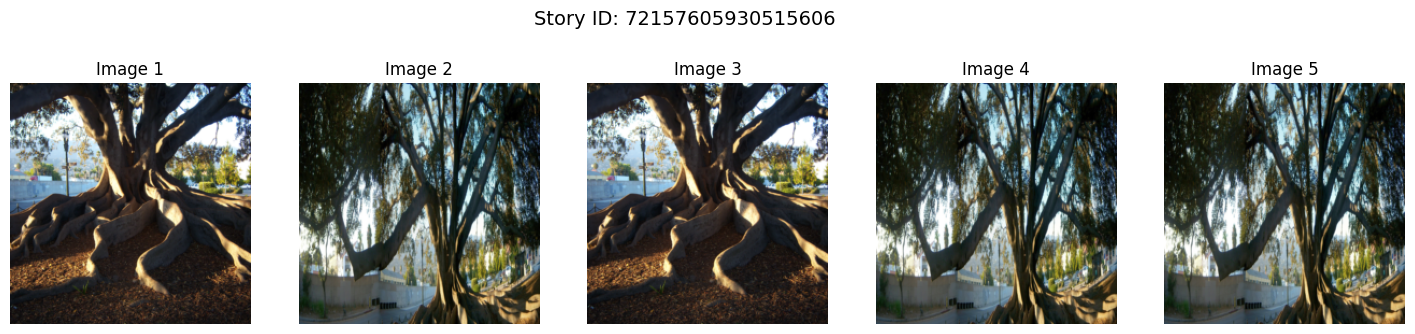


📖 STORY TEXT (SentencePiece Decoded)
Our landmark tree in town was about to be destroyed and cleared for a new mall. We found this tree when we were walking in a nearby town. Pictures of a tree are taken. They went to the botanic gardens specifically to see the large tree. We went to see the largest tree in the country.


In [44]:
import matplotlib.pyplot as plt
import torch

# ================================
# VISUALIZE ONE STORY SAMPLE
# ================================

def denormalize(img_tensor):
    """
    Reverse ImageNet normalization for visualization
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return img_tensor * std + mean


def visualize_story(dataset, idx=0):
    sample = dataset[idx]

    images = sample["images"]    # (5, 3, 224, 224)
    tokens = sample["texts"]     # (max_len,)

    # ---------------------------
    # Decode text (SentencePiece)
    # ---------------------------
    token_ids = tokens.tolist()

    # Remove padding after <eos>
    if dataset.eos_id in token_ids:
        token_ids = token_ids[:token_ids.index(dataset.eos_id)]

    decoded_text = dataset.sp.decode(token_ids)

    # Clean SentencePiece marker for readability
    decoded_text = decoded_text.replace("▁", " ").strip()

    # ---------------------------
    # Plot images
    # ---------------------------
    fig, axes = plt.subplots(1, 5, figsize=(18, 4))
    fig.suptitle(f"Story ID: {dataset.stories[idx]['story_id']}", fontsize=14)

    for i in range(5):
        img = denormalize(images[i]).clamp(0, 1)
        img = img.permute(1, 2, 0).cpu().numpy()

        axes[i].imshow(img)
        axes[i].axis("off")
        axes[i].set_title(f"Image {i+1}")

    plt.show()

    # ---------------------------
    # Print text
    # ---------------------------
    print("\n📖 STORY TEXT (SentencePiece Decoded)")
    print("=" * 80)
    print(decoded_text)
    print("=" * 80)


# ================================
# USAGE
# ================================

# Visualize first training example
visualize_story(train_dataset, idx=0)


In [14]:
import torch
import torch.nn as nn
import torchvision.models as models


class BaselineStoryModel(nn.Module):
    """
    BASELINE MODEL
    - Image encoder (CNN)
    - Text encoder (BiLSTM)
    - Simple concatenation-based fusion
    - No cross-modal attention
    """

    def __init__(
        self,
        vocab_size,
        embed_dim=512,
        txt_embed_dim=256,
        hidden_dim=512,
        num_layers=1,
        dropout=0.3
    ):
        super().__init__()

        # -------------------------
        # IMAGE ENCODER (ResNet-18)
        # -------------------------
        resnet = models.resnet18(pretrained=True)
        self.cnn = nn.Sequential(*list(resnet.children())[:-1])  # remove FC
        self.img_proj = nn.Linear(512, embed_dim)

        # Freeze CNN (baseline simplicity)
        for p in self.cnn.parameters():
            p.requires_grad = False

        # -------------------------
        # TEXT ENCODER
        # -------------------------
        self.embedding = nn.Embedding(vocab_size, txt_embed_dim, padding_idx=0)

        self.lstm = nn.LSTM(
            input_size=txt_embed_dim,
            hidden_size=hidden_dim // 2,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True
        )

        # -------------------------
        # FUSION (SIMPLE CONCAT)
        # -------------------------
        self.fusion = nn.Sequential(
            nn.Linear(embed_dim + hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # -------------------------
        # OUTPUT HEAD (TEXT)
        # -------------------------
        self.output_fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, images, input_ids):
        """
        Args:
            images: (B, 5, 3, 224, 224)
            input_ids: (B, L)

        Returns:
            logits: (B, L, vocab_size)
        """

        B, T, C, H, W = images.shape

        # -------------------------
        # IMAGE FEATURES
        # -------------------------
        images = images.view(B * T, C, H, W)
        img_feat = self.cnn(images).squeeze(-1).squeeze(-1)  # (B*T, 512)
        img_feat = self.img_proj(img_feat)                    # (B*T, D)
        img_feat = img_feat.view(B, T, -1).mean(dim=1)       # (B, D)

        # -------------------------
        # TEXT FEATURES
        # -------------------------
        txt_emb = self.embedding(input_ids)                  # (B, L, E)
        txt_out, _ = self.lstm(txt_emb)                      # (B, L, H)

        # -------------------------
        # FUSION
        # -------------------------
        img_feat = img_feat.unsqueeze(1).expand(-1, txt_out.size(1), -1)
        fused = torch.cat([img_feat, txt_out], dim=-1)       # (B, L, D+H)
        fused = self.fusion(fused)

        # -------------------------
        # OUTPUT
        # -------------------------
        logits = self.output_fc(fused)                       # (B, L, vocab)

        return logits


In [15]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# SentencePiece vocab size
vocab_size = train_dataset.sp.get_piece_size()
pad_id = train_dataset.sp.pad_id()

model = BaselineStoryModel(
    vocab_size=vocab_size,
    embed_dim=512,
    txt_embed_dim=256,
    hidden_dim=512,
    num_layers=1,
    dropout=0.3
).to(device)

print("✅ Baseline model initialized")
print("Vocab size:", vocab_size)


Device: cuda


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/zeus/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 513MB/s]


✅ Baseline model initialized
Vocab size: 8000


In [16]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss(ignore_index=pad_id)

optimizer = optim.AdamW(
    model.parameters(),
    lr=3e-4,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2,
    verbose=True
)

print("✅ Optimizer, loss, scheduler ready")


✅ Optimizer, loss, scheduler ready


In [17]:
from tqdm import tqdm

def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for batch in tqdm(loader, desc="Training"):
        images = batch["images"].to(device)
        texts  = batch["texts"].to(device)

        # Teacher forcing
        inputs = texts[:, :-1]
        targets = texts[:, 1:]

        logits = model(images, inputs)

        loss = criterion(
            logits.reshape(-1, vocab_size),
            targets.reshape(-1)
        )

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate_one_epoch(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Validation"):
            images = batch["images"].to(device)
            texts  = batch["texts"].to(device)

            inputs = texts[:, :-1]
            targets = texts[:, 1:]

            logits = model(images, inputs)

            loss = criterion(
                logits.reshape(-1, vocab_size),
                targets.reshape(-1)
            )

            total_loss += loss.item()

    return total_loss / len(loader)


In [18]:
num_epochs = 10
best_val_loss = float("inf")

for epoch in range(num_epochs):
    print(f"\n📘 Epoch {epoch+1}/{num_epochs}")

    train_loss = train_one_epoch(model, train_loader)
    val_loss   = validate_one_epoch(model, val_loader)

    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val   Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "baseline_best_model.pth")
        print("✅ Best baseline model saved")



📘 Epoch 1/10


Validation: 100%|██████████| 32/32 [00:09<00:00,  3.51it/s]


Train Loss: 4.7868
Val   Loss: 2.9801
✅ Best baseline model saved

📘 Epoch 2/10


Validation: 100%|██████████| 32/32 [00:09<00:00,  3.26it/s]


Train Loss: 2.1768
Val   Loss: 1.2823
✅ Best baseline model saved

📘 Epoch 3/10


...

Train Loss: 0.0287
Val   Loss: 0.0294
✅ Best baseline model saved

📘 Epoch 9/10


Validation: 100%|██████████| 32/32 [00:15<00:00,  2.10it/s]


Train Loss: 0.0187
Val   Loss: 0.0251
✅ Best baseline model saved

📘 Epoch 10/10


Validation: 100%|██████████| 32/32 [00:11<00:00,  2.76it/s]

Train Loss: 0.0134
Val   Loss: 0.0235
✅ Best baseline model saved


In [19]:
class CrossModalAttentionFusion(nn.Module):
    """
    Bi-directional Cross-Modal Attention Fusion
    Allows text and image modalities to attend to each other
    SentencePiece + padding safe
    """

    def __init__(self, embed_dim=512, num_heads=4, dropout=0.1):
        super().__init__()

        self.embed_dim = embed_dim
        self.num_heads = num_heads

        # Text-to-Image attention
        self.text_to_image = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )

        # Image-to-Text attention
        self.image_to_text = nn.MultiheadAttention(
            embed_dim, num_heads, dropout=dropout, batch_first=True
        )

        # Feed-forward refinement
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(embed_dim * 4, embed_dim)
        )

        # Layer norms
        self.norm1_txt = nn.LayerNorm(embed_dim)
        self.norm2_txt = nn.LayerNorm(embed_dim)
        self.norm1_img = nn.LayerNorm(embed_dim)
        self.norm2_img = nn.LayerNorm(embed_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, img_feat, txt_feat, txt_pad_mask=None):
        """
        Args:
            img_feat: (B, 5, D)        image features
            txt_feat: (B, L, D)        text token features (SentencePiece)
            txt_pad_mask: (B, L)       True for PAD tokens (optional)

        Returns:
            img_feat: (B, 5, D)
            txt_feat: (B, L, D)
        """

        # -----------------------------
        # Text attends to Image
        # -----------------------------
        txt_attn, _ = self.text_to_image(
            query=txt_feat,
            key=img_feat,
            value=img_feat,
            key_padding_mask=None  # images never padded
        )

        txt_feat = self.norm1_txt(txt_feat + self.dropout(txt_attn))
        txt_feat = self.norm2_txt(txt_feat + self.dropout(self.ff(txt_feat)))

        # -----------------------------
        # Image attends to Text (mask PAD tokens)
        # -----------------------------
        img_attn, _ = self.image_to_text(
            query=img_feat,
            key=txt_feat,
            value=txt_feat,
            key_padding_mask=txt_pad_mask  # ✅ crucial for SentencePiece
        )

        img_feat = self.norm1_img(img_feat + self.dropout(img_attn))
        img_feat = self.norm2_img(img_feat + self.dropout(self.ff(img_feat)))

        return img_feat, txt_feat


In [31]:
# ============================================================================
# CELL 8: MEMORY-EFFICIENT MODEL (Fixes OOM)
# ============================================================================

import torch
import torch.nn as nn
from torchvision import models

class CrossModalStoryModel(nn.Module):
    """
    Memory-efficient story generation model
    Decodes one step at a time without storing intermediate outputs
    """
    def __init__(self, vocab_size, embed_dim=256, num_heads=4, hidden_dim=256,
                 num_layers=1, dropout=0.1, max_seq_len=200):
        super().__init__()
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # ============================================================
        # 1. IMAGE ENCODER: ResNet50 (Pre-trained, Frozen)
        # ============================================================
        self.image_encoder = models.resnet50(pretrained=True)
        # Freeze encoder to save memory
        for param in self.image_encoder.parameters():
            param.requires_grad = False
        self.image_encoder.fc = nn.Linear(2048, embed_dim)

        # ============================================================
        # 2. TEXT ENCODER: Unidirectional LSTM (Single Layer)
        # ============================================================
        self.word_embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.text_lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,  # Single layer to save memory
            batch_first=True,
            dropout=0 if num_layers == 1 else dropout,
            bidirectional=False  # Unidirectional to save memory
        )

        # ============================================================
        # 3. SIMPLIFIED FUSION (Just concatenation)
        # ============================================================
        # Average image features and concatenate with text
        self.fusion_proj = nn.Linear(embed_dim + hidden_dim, embed_dim)

        # ============================================================
        # 4. DECODER: Single-step LSTM
        # ============================================================
        self.decoder_lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0
        )

        # Output projection
        self.output_proj = nn.Linear(hidden_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, images, texts):
        """
        Args:
            images: (batch_size, 5, 3, 224, 224)
            texts: (batch_size, seq_len)

        Returns:
            logits: (batch_size, seq_len, vocab_size)
        """
        batch_size = images.shape[0]
        seq_len = texts.shape[1]

        # ============================================================
        # STAGE 1: IMAGE ENCODING (Frozen)
        # ============================================================
        with torch.no_grad():
            images_flat = images.view(-1, 3, 224, 224)
            img_features = self.image_encoder(images_flat)  # (batch*5, embed_dim)
            img_features = img_features.view(batch_size, 5, self.embed_dim)

            # Average 5 images into 1 context vector
            img_context = img_features.mean(dim=1)  # (batch, embed_dim)

        # ============================================================
        # STAGE 2: TEXT ENCODING
        # ============================================================
        text_embed = self.word_embed(texts)  # (batch, seq_len, embed_dim)
        text_lstm_out, (text_h, text_c) = self.text_lstm(text_embed)
        # text_h: (num_layers, batch, hidden_dim)

        # ============================================================
        # STAGE 3: FUSION - Create context for each position
        # ============================================================
        # Concatenate image context with each text position
        img_context_expanded = img_context.unsqueeze(1).expand(-1, seq_len, -1)
        # (batch, seq_len, embed_dim + embed_dim) → (batch, seq_len, embed_dim)
        fused = torch.cat([text_lstm_out, img_context_expanded], dim=2)
        fused = self.fusion_proj(fused)
        fused = self.dropout(fused)

        # ============================================================
        # STAGE 4: DECODING (Memory-Efficient)
        # ============================================================
        # Initialize hidden state
        hidden = (text_h, text_c)

        # Generate logits step-by-step (don't store intermediate results)
        logits_list = []

        for t in range(seq_len):
            # Decode one token at a time
            decoder_input = fused[:, t:t+1]  # (batch, 1, embed_dim)
            decoder_output, hidden = self.decoder_lstm(decoder_input, hidden)
            # decoder_output: (batch, 1, hidden_dim)

            logit = self.output_proj(decoder_output)  # (batch, 1, vocab_size)
            logits_list.append(logit)

        # Concatenate all logits
        logits = torch.cat(logits_list, dim=1)  # (batch, seq_len, vocab_size)

        return logits

print("✓ Memory-efficient CrossModalStoryModel defined")

✓ Memory-efficient CrossModalStoryModel defined


In [32]:
REAL_VOCAB_SIZE = len(train_dataset.sp)
print(f"✅ Vocabulary Size: {REAL_VOCAB_SIZE}\n")

# Initialize model with memory-efficient architecture
model = CrossModalStoryModel(
    vocab_size=REAL_VOCAB_SIZE,
    embed_dim=256,          # Reduced from 512
    num_heads=4,
    hidden_dim=256,         # Reduced from 512
    num_layers=1,           # Reduced from 2 (saves memory)
    dropout=0.1,
    max_seq_len=200
)
model.to(device)

print(f"Model Architecture:")
print(f"  Embedding dim: 256 (reduced)")
print(f"  Hidden dim: 256 (reduced)")
print(f"  Num layers: 1 (single layer)")
print(f"  Frozen ResNet50: Yes (saves memory)\n")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model Parameters:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")
print(f"  (ResNet50 is frozen)\n")

# Setup optimizer (smaller learning rate)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-5)
criterion = torch.nn.CrossEntropyLoss(ignore_index=0)

# Learning rate scheduler
def lr_lambda(step):
    """Warmup + Cosine decay"""
    warmup_steps = 2
    total_steps = 10  # num_epochs
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    return max(0.0, float(total_steps - step) / float(max(1, total_steps - warmup_steps)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f"✓ Training setup complete:")
print(f"  Optimizer: Adam (lr=3e-4, smaller)")
print(f"  Loss: CrossEntropyLoss (ignoring pad token)")
print(f"  LR Scheduler: Warmup + Cosine decay")

✅ Vocabulary Size: 8000

Model Architecture:
  Embedding dim: 256 (reduced)
  Hidden dim: 256 (reduced)
  Num layers: 1 (single layer)
  Frozen ResNet50: Yes (saves memory)

Model Parameters:
  Total: 29,320,576
  Trainable: 5,812,544
  (ResNet50 is frozen)

✓ Training setup complete:
  Optimizer: Adam (lr=3e-4, smaller)
  Loss: CrossEntropyLoss (ignoring pad token)
  LR Scheduler: Warmup + Cosine decay


In [33]:
# See what's actually in your batch
batch = next(iter(train_loader))

print(f"Batch has {len(batch)} items:")
for i, item in enumerate(batch):
    if isinstance(item, torch.Tensor):
        print(f"  [{i}] Tensor: {item.shape}")
    else:
        print(f"  [{i}] {type(item).__name__}: {item}")

Batch has 2 items:
  [0] str: images
  [1] str: texts


In [34]:
# ============================================================================
# CELL 10: TRAINING (FIX 1: NEXT-TOKEN SHIFT / TEACHER FORCING)
# ============================================================================


from tqdm import tqdm
import torch

def train_epoch(epoch, num_epochs):
    model.train()
    total_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [TRAIN]")

    for batch_idx, batch in enumerate(pbar):
        # Unpack batch
        if isinstance(batch, dict):
            images = batch["images"]
            texts  = batch["texts"]
        else:
            images, texts = batch[0], batch[1]

        images = images.to(device, non_blocking=True)
        texts  = texts.to(device, non_blocking=True)

        # Reshape if 3D (safety)
        if texts.dim() == 3:
            texts = texts.reshape(texts.shape[0], -1)

        # -----------------------------
        # FIX 1: shift for next-token LM
        # inp:  <start> w1 w2 ... w(n-1)
        # tgt:  w1     w2 ... w(n-1) <end>
        # -----------------------------
        inp = texts[:, :-1]   # [B, L-1]
        tgt = texts[:,  1:]   # [B, L-1]

        # Forward pass
        logits = model(images, inp)  # expected: [B, L-1, V]

        # Debug first batch
        if batch_idx == 0 and epoch == 0:
            print(f"\n🔍 DEBUG: inp shape: {inp.shape}, tgt shape: {tgt.shape}, logits shape: {logits.shape}")

        # Flatten for CrossEntropyLoss: [B*(L-1), V] vs [B*(L-1)]
        logits_flat  = logits.reshape(-1, logits.shape[-1])
        targets_flat = tgt.reshape(-1)

        # Check match (should always match now)
        if logits_flat.shape[0] != targets_flat.shape[0]:
            print(f"\n❌ SHAPE MISMATCH!")
            print(f"  Logits:  {logits_flat.shape}")
            print(f"  Targets: {targets_flat.shape}")
            raise ValueError("Shape mismatch in shifted training.")

        # Loss + backward
        loss = criterion(logits_flat, targets_flat)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    return total_loss / len(train_loader)


def validate(epoch, num_epochs):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [VAL]")

        for batch in pbar:
            if isinstance(batch, dict):
                images = batch["images"]
                texts  = batch["texts"]
            else:
                images, texts = batch[0], batch[1]

            images = images.to(device, non_blocking=True)
            texts  = texts.to(device, non_blocking=True)

            if texts.dim() == 3:
                texts = texts.reshape(texts.shape[0], -1)

            # FIX 1: shift for validation too (same objective)
            inp = texts[:, :-1]
            tgt = texts[:,  1:]

            logits = model(images, inp)

            logits_flat  = logits.reshape(-1, logits.shape[-1])
            targets_flat = tgt.reshape(-1)

            loss = criterion(logits_flat, targets_flat)
            total_loss += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    return total_loss / len(val_loader)


# ============================================================================
# RUN TRAINING
# ============================================================================

print("\n" + "="*70)
print(" STARTING TRAINING")
print("="*70)

num_epochs = 10
best_val_loss = float("inf")
patience = 3
patience_counter = 0

for epoch in range(num_epochs):
    train_loss = train_epoch(epoch, num_epochs)
    val_loss = validate(epoch, num_epochs)
    scheduler.step()

    print(f"✓ Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/teamspace/studios/this_studio/results/best_model.pth")
        print("  → Best model saved!")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\n  Early stopping at epoch {epoch+1}")
            break

print("\n TRAINING COMPLETE")


 STARTING TRAINING


Epoch 1/10 [TRAIN]:   0%|          | 1/251 [00:00<02:51,  1.46it/s, loss=8.9858]


🔍 DEBUG: inp shape: torch.Size([32, 199]), tgt shape: torch.Size([32, 199]), logits shape: torch.Size([32, 199, 8000])


Epoch 1/10 [VAL]: 100%|██████████| 32/32 [00:25<00:00,  1.27it/s, loss=8.9872]


✓ Epoch 1: Train Loss=8.9867, Val Loss=8.9871
  → Best model saved!


...

✓ Epoch 8: Train Loss=4.9094, Val Loss=4.8857
  → Best model saved!


Epoch 9/10 [VAL]: 100%|██████████| 32/32 [00:13<00:00,  2.44it/s, loss=4.7988]


✓ Epoch 9: Train Loss=4.8610, Val Loss=4.8555
  → Best model saved!


Epoch 10/10 [VAL]: 100%|██████████| 32/32 [00:08<00:00,  3.65it/s, loss=4.7759]


✓ Epoch 10: Train Loss=4.8304, Val Loss=4.8391
  → Best model saved!

 TRAINING COMPLETE


In [37]:
print("\n" + "="*70)
print("📊 EVALUATING ON TEST SET")
print("="*70 + "\n")

ckpt_path = "/teamspace/studios/this_studio/results/best_model.pth"   # change to your actual path if local
# Example for Windows:
# ckpt_path = r"C:\Users\umama\Documents\Vishnu\best_model.pth"

# ------------------------------------------------------------
# 1) Re-create the model object (because you overwrote `model`)
# ------------------------------------------------------------
vocab_size = len(train_dataset.sp)  # must match training vocab
model = CrossModalStoryModel(vocab_size=vocab_size)
model.to(device)

# ------------------------------------------------------------
# 2) Load checkpoint correctly (DO NOT overwrite model)
# ------------------------------------------------------------
checkpoint = torch.load(ckpt_path, map_location=device)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    load_result = model.load_state_dict(checkpoint["model_state_dict"], strict=False)
else:
    load_result = model.load_state_dict(checkpoint, strict=False)

print("Load report:")
print("  Missing keys   :", load_result.missing_keys)
print("  Unexpected keys:", load_result.unexpected_keys)

model.eval()


@torch.no_grad()
def test():
    """Evaluate on test set"""
    total_loss = 0.0
    pbar = tqdm(test_loader, desc="TEST SET EVALUATION")

    for batch in pbar:
        images = batch["images"].to(device, non_blocking=True)
        texts  = batch["texts"].to(device, non_blocking=True)

        logits = model(images, texts)

        bsz, seq_len, vocab_size_ = logits.shape
        logits_flat  = logits.view(bsz * seq_len, vocab_size_)
        targets_flat = texts.view(bsz * seq_len)

        loss = criterion(logits_flat, targets_flat)
        total_loss += loss.item()
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = total_loss / len(test_loader)
    perplexity = float(np.exp(avg_loss))
    return avg_loss, perplexity


# Evaluate
test_loss, perplexity = test()

# Print results
print("\n" + "="*70)
print("📊 FINAL TEST RESULTS")
print("="*70)
print(f"Test Loss:        {test_loss:.4f}")
print(f"Test Perplexity:  {perplexity:.4f}")
print("="*70)

print("\n✓ Training pipeline complete!")
print(f"  Model loaded from: {ckpt_path}")
print("  Ready for inference and evaluation!")


# Save summary (change path if local Windows)
summary_path = "/content/training_summary.txt"
# Example Windows:
# summary_path = r"C:\Users\umama\Documents\Vishnu\training_summary.txt"

with open(summary_path, "w", encoding="utf-8") as f:
    f.write("="*70 + "\n")
    f.write("CROSS-MODAL ATTENTION FUSION - TRAINING SUMMARY\n")
    f.write("="*70 + "\n\n")
    f.write("Dataset: VIST (Visual Storytelling)\n")
    f.write(f"Train samples: {len(train_dataset):,}\n")
    f.write(f"Val samples:   {len(val_dataset):,}\n")
    f.write(f"Test samples:  {len(test_dataset):,}\n")
    f.write(f"Vocabulary size: {len(train_dataset.sp):,}\n\n")
    f.write(f"Model Parameters: {total_params:,}\n")
    f.write(f"Trainable Parameters: {trainable_params:,}\n\n")
    f.write(f"Test Loss: {test_loss:.4f}\n")
    f.write(f"Test Perplexity: {perplexity:.4f}\n")
    f.write("="*70 + "\n")

print(f"\n✓ Summary saved to {summary_path}")


📊 EVALUATING ON TEST SET

Load report:
  Missing keys   : []
  Unexpected keys: []


TEST SET EVALUATION:   0%|          | 0/32 [00:00<?, ?it/s]

TEST SET EVALUATION: 100%|██████████| 32/32 [00:18<00:00,  1.74it/s, loss=7.8771]


📊 FINAL TEST RESULTS
Test Loss:        7.8920
Test Perplexity:  2675.9042

✓ Training pipeline complete!
  Model loaded from: /teamspace/studios/this_studio/results/best_model.pth
  Ready for inference and evaluation!

✓ Summary saved to /content/training_summary.txt


In [38]:
model.eval()

batch = next(iter(test_loader))
images = batch["images"].to(device)   # [B, 5, 3, 224, 224]
texts  = batch["texts"].to(device)    # [B, 200]

# take one item
img1 = images[0:1]   # keep batch dim => [1, 5, 3, 224, 224]
gt  = texts[0].tolist()

In [39]:
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def evaluate_model(model, loader, sp, max_samples=200):
    rouge = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=True)
    smoothie = SmoothingFunction().method4

    rouge_scores = []
    bleu_scores = []

    for i, batch in enumerate(loader):
        if i >= max_samples:
            break

        images = batch["images"].to(device)
        texts  = batch["texts"]

        # Ground truth
        gt_ids = texts[0].tolist()
        if sp.eos_id() in gt_ids:
            gt_ids = gt_ids[:gt_ids.index(sp.eos_id())]

        gt_text = sp.decode(gt_ids).replace("▁", " ").strip()

        # Prediction
        pred_text = generate_story(model, images[:1], sp)

        rouge_l = rouge.score(gt_text, pred_text)["rougeL"].fmeasure
        bleu = sentence_bleu([gt_text.split()], pred_text.split(), smoothing_function=smoothie)

        rouge_scores.append(rouge_l)
        bleu_scores.append(bleu)

    return sum(rouge_scores)/len(rouge_scores), sum(bleu_scores)/len(bleu_scores)
